<a href="https://colab.research.google.com/github/naumhasan1200-beep/cover-page/blob/main/cover_page.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload your Lab Report PDF:


Saving Lab_Report_01_Mechanical_Eng.pdf to Lab_Report_01_Mechanical_Eng (5).pdf
Upload the gear background image:


Saving WhatsApp Image 2026-03-18 at 3.34.31 PM.jpeg to WhatsApp Image 2026-03-18 at 3.34.31 PM.jpeg
Logo ready.
Background ready.
Cover built.


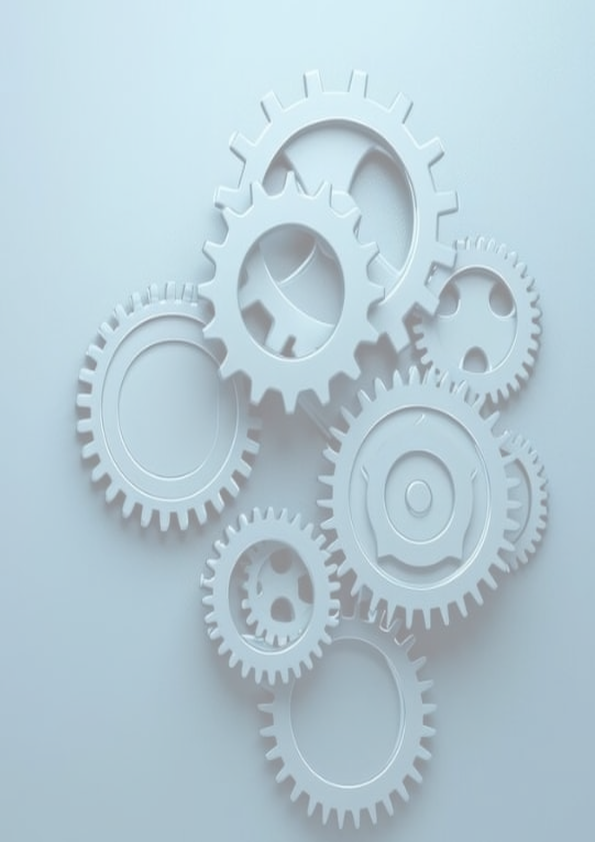

Done! Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("Upload the gear background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

import fitz, os, io
from PIL import Image, ImageEnhance
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from pypdf import PdfReader, PdfWriter

# --- Extract logo & remove white background ---
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path = "cuet_logo.png"
    logo_img = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    datas = logo_img.getdata()
    new_data = []
    for item in datas:
        r, g, b, a = item
        if r > 225 and g > 225 and b > 225:
            new_data.append((255, 255, 255, 0))
        else:
            new_data.append(item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
    print("Logo ready.")
doc.close()

# --- Background: full page, sharp, 45% opacity ---
A4_PX = (595, 842)
bg = Image.open(bg_image_path).convert("RGBA")
bg = bg.resize(A4_PX, Image.LANCZOS)
r, g, b, a = bg.split()
a = ImageEnhance.Brightness(a).enhance(0.45)
bg.putalpha(a)
white_bg = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
white_bg.paste(bg, (0, 0), bg)
white_bg.convert("RGB").save("bg_processed.png")
print("Background ready.")

W, H = A4
NAVY       = colors.HexColor("#0A2342")
GOLD       = colors.HexColor("#B8860B")
LIGHT_GOLD = colors.HexColor("#DAA520")
BLACK      = colors.HexColor("#0D0D0D")

OUTPUT_PDF = "cover_new.pdf"
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)

# White base
c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)

# Full page gear background
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# ── BORDER ───────────────────────────────────────────────
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)
c.setStrokeColor(LIGHT_GOLD)
c.setLineWidth(1.0)
c.rect(15, 15, W-30, H-30, fill=0, stroke=1)

# Corner diamonds
def diamond(px, py, s=5):
    c.setFillColor(GOLD)
    p = c.beginPath()
    p.moveTo(px, py+s); p.lineTo(px+s, py)
    p.lineTo(px, py-s); p.lineTo(px-s, py)
    p.close()
    c.drawPath(p, fill=1, stroke=0)

for px, py in [(10,10),(W-10,10),(10,H-10),(W-10,H-10)]:
    diamond(px, py, 6)
diamond(W/2, 10); diamond(W/2, H-10)
diamond(10, H/2); diamond(W-10, H/2)

# ── HELPERS ──────────────────────────────────────────────
def dc(text, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawString(x, y, text)

# ── UNIVERSITY NAME ───────────────────────────────────────
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
c.setStrokeColor(LIGHT_GOLD)
c.setLineWidth(1.2)
c.line(30, H-58, W-30, H-58)
dc("Department of Mechanical Engineering",
   H-74, "Helvetica-Bold", 12, NAVY)

# ── LOGO ──────────────────────────────────────────────────
LOGO_SIZE = 148
LOGO_Y    = H - 74 - LOGO_SIZE - 16
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path,
                (W - LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

c.setStrokeColor(LIGHT_GOLD)
c.setLineWidth(1.0)
c.line(30, LOGO_Y-10, W-30, LOGO_Y-10)

# ── EXPERIMENT NO & NAME ──────────────────────────────────
LBL_X  = 38
VAL_X  = LBL_X + 158
BOX_W  = W - LBL_X - 38

EXP_NO_Y = LOGO_Y - 28
EXP_NM_Y = EXP_NO_Y - 22

dl("Experiment No  :", LBL_X, EXP_NO_Y, "Helvetica-Bold", 11, NAVY)
dl("03",              VAL_X, EXP_NO_Y,  "Helvetica",      11, BLACK)
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, "Helvetica-Bold", 11, NAVY)

# Experiment answer box — white with small padding
EXP_BOX_Y = EXP_NM_Y - 26
EXP_BOX_H = 24
c.setFillColor(colors.Color(1, 1, 1, alpha=0.88))
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=1, stroke=0)
c.setStrokeColor(LIGHT_GOLD)
c.setLineWidth(0.9)
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=0, stroke=1)

c.setStrokeColor(LIGHT_GOLD)
c.setLineWidth(1.0)
c.line(30, EXP_BOX_Y-12, W-30, EXP_BOX_Y-12)

# ── STUDENT INFO TABLE ────────────────────────────────────
INFO_TOP    = EXP_BOX_Y - 20
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            "Nafiu Hasan Naum"),
    ("Student ID",      "2203098"),
    ("Section",         "B2"),
    ("Level",           "3"),
    ("Term",            "1"),
    ("Course No",       ""),
    ("Course Title",    ""),
    ("Experiment Date", ""),
    ("Submission Date", ""),
]

NUM_ROWS = len(fields)
ROW_H    = INFO_H / NUM_ROWS
COL_LBL  = LBL_X
COL_COL  = COL_LBL + 132
COL_VAL  = COL_COL + 12

for i, (label, value) in enumerate(fields):
    y = INFO_TOP - (i + 0.68) * ROW_H

    # White background only behind each row text — small tight box
    row_bg_y = y - ROW_H * 0.36
    row_bg_h = ROW_H * 0.90
    c.setFillColor(colors.Color(1, 1, 1, alpha=0.72))
    c.rect(LBL_X - 4, row_bg_y, BOX_W + 4, row_bg_h, fill=1, stroke=0)

    dl(label, COL_LBL, y, "Helvetica-Bold", 10.5, NAVY)
    dl(":",   COL_COL, y, "Helvetica-Bold", 10.5, NAVY)
    if value:
        dl(value, COL_VAL, y, "Helvetica", 10.5, BLACK)

    # Row divider
    c.setStrokeColor(colors.Color(0.6, 0.6, 0.8, alpha=0.4))
    c.setLineWidth(0.4)
    c.line(LBL_X, row_bg_y, LBL_X + BOX_W, row_bg_y)

# Gold outer box around info table
c.setStrokeColor(LIGHT_GOLD)
c.setLineWidth(1.0)
c.rect(LBL_X - 4, INFO_BOTTOM, BOX_W + 4, INFO_H, fill=0, stroke=1)

c.save()
print("Cover built.")

# --- Merge ---
orig   = PdfReader(input_pdf)
cover  = PdfReader(OUTPUT_PDF)
writer = PdfWriter()
writer.add_page(cover.pages[0])
for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

from IPython.display import display
display(Image.open("bg_processed.png"))
print("Done! Downloading...")
files.download(FINAL)

Upload your Lab Report PDF:


Saving Lab_Report_01_Mechanical_Eng.pdf to Lab_Report_01_Mechanical_Eng (6).pdf
Upload the gear background image:


Saving WhatsApp Image 2026-03-18 at 3.34.31 PM.jpeg to WhatsApp Image 2026-03-18 at 3.34.31 PM (2).jpeg
Logo ready.
Background ready.
Cover built.


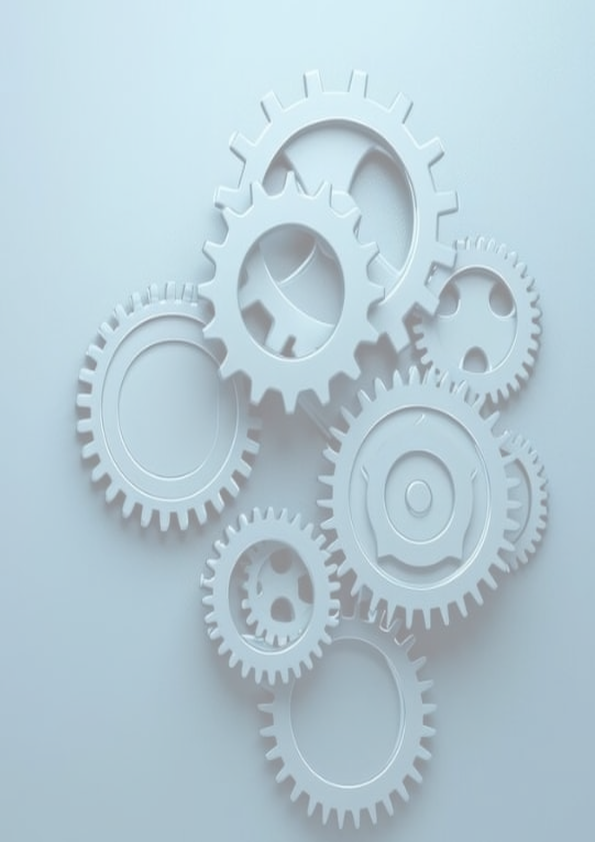

Done! Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("Upload the gear background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

import fitz, os, io
from PIL import Image, ImageEnhance
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from pypdf import PdfReader, PdfWriter

# --- Extract logo & remove white background ---
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path = "cuet_logo.png"
    logo_img = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    datas = logo_img.getdata()
    new_data = []
    for item in datas:
        r, g, b, a = item
        if r > 225 and g > 225 and b > 225:
            new_data.append((255, 255, 255, 0))
        else:
            new_data.append(item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
    print("Logo ready.")
doc.close()

# --- Background: full page, sharp, 45% opacity ---
A4_PX = (595, 842)
bg = Image.open(bg_image_path).convert("RGBA")
bg = bg.resize(A4_PX, Image.LANCZOS)
r, g, b, a = bg.split()
a = ImageEnhance.Brightness(a).enhance(0.45)
bg.putalpha(a)
white_bg = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
white_bg.paste(bg, (0, 0), bg)
white_bg.convert("RGB").save("bg_processed.png")
print("Background ready.")

W, H = A4
NAVY  = colors.HexColor("#0A2342")
BLACK = colors.HexColor("#0D0D0D")

OUTPUT_PDF = "cover_new.pdf"
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)

# White base
c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)

# Full page gear background
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# ── SIMPLE CLEAN BORDER — navy only, no gold marks ───────
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)

# ── HELPERS ──────────────────────────────────────────────
def dc(text, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawString(x, y, text)

# ── UNIVERSITY NAME ───────────────────────────────────────
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
dc("Department of Mechanical Engineering",
   H-72, "Helvetica-Bold", 12, NAVY)

# ── LOGO ──────────────────────────────────────────────────
LOGO_SIZE = 148
LOGO_Y    = H - 72 - LOGO_SIZE - 18
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path,
                (W - LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

# ── EXPERIMENT NO & NAME ──────────────────────────────────
LBL_X = 38
VAL_X = LBL_X + 158
BOX_W = W - LBL_X - 38

EXP_NO_Y = LOGO_Y - 28
EXP_NM_Y = EXP_NO_Y - 22

dl("Experiment No  :", LBL_X, EXP_NO_Y, "Helvetica-Bold", 11, NAVY)
dl("03",              VAL_X, EXP_NO_Y,  "Helvetica",      11, BLACK)
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, "Helvetica-Bold", 11, NAVY)

# Experiment answer box
EXP_BOX_Y = EXP_NM_Y - 26
EXP_BOX_H = 24
c.setFillColor(colors.Color(1, 1, 1, alpha=0.88))
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=1, stroke=0)
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=0, stroke=1)

# ── STUDENT INFO TABLE ────────────────────────────────────
INFO_TOP    = EXP_BOX_Y - 20
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            "Nafiu Hasan Naum"),
    ("Student ID",      "2203098"),
    ("Section",         "B2"),
    ("Level",           "3"),
    ("Term",            "1"),
    ("Course No",       ""),
    ("Course Title",    ""),
    ("Experiment Date", ""),
    ("Submission Date", ""),
]

NUM_ROWS = len(fields)
ROW_H    = INFO_H / NUM_ROWS
COL_LBL  = LBL_X
COL_COL  = COL_LBL + 132
COL_VAL  = COL_COL + 12

for i, (label, value) in enumerate(fields):
    y = INFO_TOP - (i + 0.68) * ROW_H

    row_bg_y = y - ROW_H * 0.36
    row_bg_h = ROW_H * 0.90
    c.setFillColor(colors.Color(1, 1, 1, alpha=0.72))
    c.rect(LBL_X - 4, row_bg_y, BOX_W + 4, row_bg_h, fill=1, stroke=0)

    dl(label, COL_LBL, y, "Helvetica-Bold", 10.5, NAVY)
    dl(":",   COL_COL, y, "Helvetica-Bold", 10.5, NAVY)
    if value:
        dl(value, COL_VAL, y, "Helvetica", 10.5, BLACK)

    c.setStrokeColor(colors.Color(0.6, 0.6, 0.8, alpha=0.4))
    c.setLineWidth(0.4)
    c.line(LBL_X, row_bg_y, LBL_X + BOX_W, row_bg_y)

# Outer box around info table
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.rect(LBL_X - 4, INFO_BOTTOM, BOX_W + 4, INFO_H, fill=0, stroke=1)

c.save()
print("Cover built.")

# --- Merge ---
orig   = PdfReader(input_pdf)
cover  = PdfReader(OUTPUT_PDF)
writer = PdfWriter()
writer.add_page(cover.pages[0])
for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

from IPython.display import display
display(Image.open("bg_processed.png"))
print("Done! Downloading...")
files.download(FINAL)

Upload your Lab Report PDF:


Saving Lab_Report_01_Mechanical_Eng.pdf to Lab_Report_01_Mechanical_Eng (7).pdf
Upload the gear background image:


Saving WhatsApp Image 2026-03-18 at 3.34.31 PM.jpeg to WhatsApp Image 2026-03-18 at 3.34.31 PM (3).jpeg
Logo ready.
Background ready — grayscale gear shapes only.
Cover built.


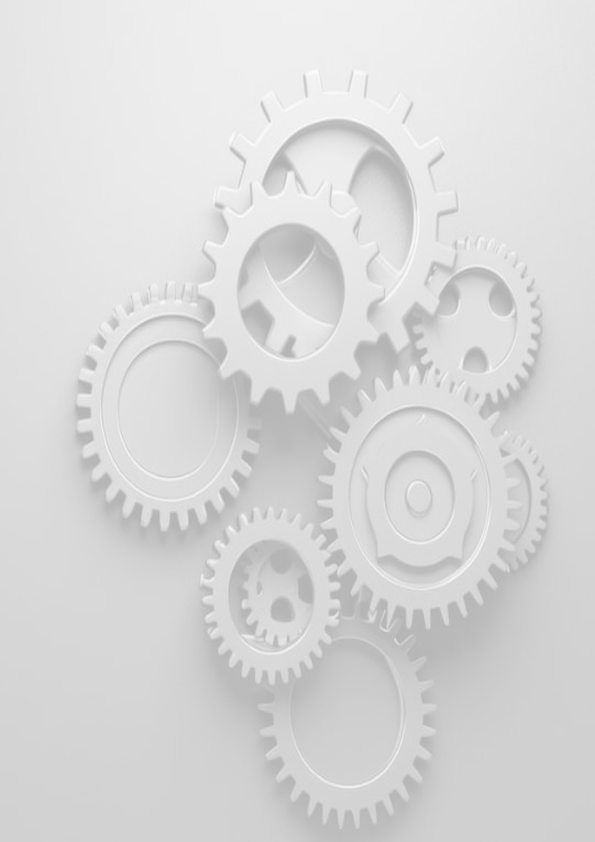

Done! Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("Upload the gear background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

import fitz, os, io
from PIL import Image, ImageEnhance, ImageOps
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from pypdf import PdfReader, PdfWriter

# --- Extract logo & remove white background ---
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path = "cuet_logo.png"
    logo_img = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    datas = logo_img.getdata()
    new_data = []
    for item in datas:
        r, g, b, a = item
        if r > 225 and g > 225 and b > 225:
            new_data.append((255, 255, 255, 0))
        else:
            new_data.append(item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
    print("Logo ready.")
doc.close()

# --- Background: convert to pure grayscale so NO original colours remain ---
# Only the gear SHAPES/DESIGN will show, not the gold/silver colours
A4_PX = (595, 842)
bg = Image.open(bg_image_path).convert("L")        # grayscale — strips all colour
bg = bg.resize(A4_PX, Image.LANCZOS)
bg = bg.convert("RGBA")

# Set opacity to 30% — gear shapes visible but subtle
r, g, b, a = bg.split()
a = ImageEnhance.Brightness(a).enhance(0.30)
bg.putalpha(a)

white_bg = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
white_bg.paste(bg, (0, 0), bg)
white_bg.convert("RGB").save("bg_processed.png")
print("Background ready — grayscale gear shapes only.")

W, H = A4
NAVY  = colors.HexColor("#0A2342")
BLACK = colors.HexColor("#0D0D0D")

OUTPUT_PDF = "cover_new.pdf"
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)

# White base
c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)

# Gear background — shapes only, no original colour
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# ── CLEAN NAVY BORDER ─────────────────────────────────────
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)

# ── HELPERS ──────────────────────────────────────────────
def dc(text, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawString(x, y, text)

# ── UNIVERSITY NAME ───────────────────────────────────────
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
dc("Department of Mechanical Engineering",
   H-72, "Helvetica-Bold", 12, NAVY)

# ── LOGO ──────────────────────────────────────────────────
LOGO_SIZE = 148
LOGO_Y    = H - 72 - LOGO_SIZE - 18
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path,
                (W - LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

# ── EXPERIMENT NO & NAME ──────────────────────────────────
LBL_X = 38
VAL_X = LBL_X + 158
BOX_W = W - LBL_X - 38

EXP_NO_Y = LOGO_Y - 28
EXP_NM_Y = EXP_NO_Y - 22

dl("Experiment No  :", LBL_X, EXP_NO_Y, "Helvetica-Bold", 11, NAVY)
dl("03",              VAL_X, EXP_NO_Y,  "Helvetica",      11, BLACK)
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, "Helvetica-Bold", 11, NAVY)

# Experiment answer box
EXP_BOX_Y = EXP_NM_Y - 26
EXP_BOX_H = 24
c.setFillColor(colors.Color(1, 1, 1, alpha=0.88))
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=1, stroke=0)
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=0, stroke=1)

# ── STUDENT INFO TABLE ────────────────────────────────────
INFO_TOP    = EXP_BOX_Y - 20
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            "Nafiu Hasan Naum"),
    ("Student ID",      "2203098"),
    ("Section",         "B2"),
    ("Level",           "3"),
    ("Term",            "1"),
    ("Course No",       ""),
    ("Course Title",    ""),
    ("Experiment Date", ""),
    ("Submission Date", ""),
]

NUM_ROWS = len(fields)
ROW_H    = INFO_H / NUM_ROWS
COL_LBL  = LBL_X
COL_COL  = COL_LBL + 132
COL_VAL  = COL_COL + 12

for i, (label, value) in enumerate(fields):
    y = INFO_TOP - (i + 0.68) * ROW_H

    row_bg_y = y - ROW_H * 0.36
    row_bg_h = ROW_H * 0.90
    c.setFillColor(colors.Color(1, 1, 1, alpha=0.72))
    c.rect(LBL_X - 4, row_bg_y, BOX_W + 4, row_bg_h, fill=1, stroke=0)

    dl(label, COL_LBL, y, "Helvetica-Bold", 10.5, NAVY)
    dl(":",   COL_COL, y, "Helvetica-Bold", 10.5, NAVY)
    if value:
        dl(value, COL_VAL, y, "Helvetica", 10.5, BLACK)

    c.setStrokeColor(colors.Color(0.6, 0.6, 0.8, alpha=0.4))
    c.setLineWidth(0.4)
    c.line(LBL_X, row_bg_y, LBL_X + BOX_W, row_bg_y)

# Outer box around info table
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.rect(LBL_X - 4, INFO_BOTTOM, BOX_W + 4, INFO_H, fill=0, stroke=1)

c.save()
print("Cover built.")

# --- Merge ---
orig   = PdfReader(input_pdf)
cover  = PdfReader(OUTPUT_PDF)
writer = PdfWriter()
writer.add_page(cover.pages[0])
for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

from IPython.display import display
display(Image.open("bg_processed.png"))
print("Done! Downloading...")
files.download(FINAL)

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("\nUpload the gear background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

# ════════════════════════════════════════════════════════════
#  TAKE ALL INPUTS FROM USER
# ════════════════════════════════════════════════════════════
print("\n" + "="*50)
print("   FILL IN YOUR LAB REPORT DETAILS")
print("="*50)

exp_no        = input("Experiment No          : ").strip()
exp_name      = input("Name of the Experiment : ").strip()
student_name  = input("Name                   : ").strip()
student_id    = input("Student ID             : ").strip()
section       = input("Section                : ").strip()
level         = input("Level                  : ").strip()
term          = input("Term                   : ").strip()
course_no     = input("Course No              : ").strip()
course_title  = input("Course Title           : ").strip()
exp_date      = input("Experiment Date        : ").strip()
sub_date      = input("Submission Date        : ").strip()

print("\n✅ All inputs received. Building cover page...")

import fitz, os, io
from PIL import Image, ImageEnhance
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from pypdf import PdfReader, PdfWriter

# --- Extract logo & remove white background ---
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path = "cuet_logo.png"
    logo_img = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    datas = logo_img.getdata()
    new_data = []
    for item in datas:
        r, g, b, a = item
        if r > 225 and g > 225 and b > 225:
            new_data.append((255, 255, 255, 0))
        else:
            new_data.append(item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
doc.close()

# --- Background: grayscale gear shapes only, 30% opacity ---
A4_PX = (595, 842)
bg = Image.open(bg_image_path).convert("L")
bg = bg.resize(A4_PX, Image.LANCZOS)
bg = bg.convert("RGBA")
r, g, b, a = bg.split()
a = ImageEnhance.Brightness(a).enhance(0.30)
bg.putalpha(a)
white_bg = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
white_bg.paste(bg, (0, 0), bg)
white_bg.convert("RGB").save("bg_processed.png")

W, H = A4
NAVY  = colors.HexColor("#0A2342")
BLACK = colors.HexColor("#0D0D0D")

OUTPUT_PDF = "cover_new.pdf"
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)

c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# Navy border
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)

def dc(text, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawString(x, y, text)

# University & Department
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
dc("Department of Mechanical Engineering",
   H-72, "Helvetica-Bold", 12, NAVY)

# Logo
LOGO_SIZE = 148
LOGO_Y    = H - 72 - LOGO_SIZE - 18
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path,
                (W - LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

# Experiment No & Name
LBL_X = 38
VAL_X = LBL_X + 158
BOX_W = W - LBL_X - 38

EXP_NO_Y = LOGO_Y - 28
EXP_NM_Y = EXP_NO_Y - 22

dl("Experiment No  :", LBL_X, EXP_NO_Y, "Helvetica-Bold", 11, NAVY)
dl(exp_no,            VAL_X, EXP_NO_Y,  "Helvetica",      11, BLACK)
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, "Helvetica-Bold", 11, NAVY)

# Experiment name answer box
EXP_BOX_Y = EXP_NM_Y - 26
EXP_BOX_H = 24
c.setFillColor(colors.Color(1, 1, 1, alpha=0.88))
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=1, stroke=0)
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=0, stroke=1)
# Write experiment name inside the box
dl(exp_name, LBL_X + 6, EXP_BOX_Y + 7, "Helvetica", 10, BLACK)

# Student info table
INFO_TOP    = EXP_BOX_Y - 20
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            student_name),
    ("Student ID",      student_id),
    ("Section",         section),
    ("Level",           level),
    ("Term",            term),
    ("Course No",       course_no),
    ("Course Title",    course_title),
    ("Experiment Date", exp_date),
    ("Submission Date", sub_date),
]

NUM_ROWS = len(fields)
ROW_H    = INFO_H / NUM_ROWS
COL_LBL  = LBL_X
COL_COL  = COL_LBL + 132
COL_VAL  = COL_COL + 12

for i, (label, value) in enumerate(fields):
    y = INFO_TOP - (i + 0.68) * ROW_H

    row_bg_y = y - ROW_H * 0.36
    row_bg_h = ROW_H * 0.90
    c.setFillColor(colors.Color(1, 1, 1, alpha=0.72))
    c.rect(LBL_X - 4, row_bg_y, BOX_W + 4, row_bg_h, fill=1, stroke=0)

    dl(label,  COL_LBL, y, "Helvetica-Bold", 10.5, NAVY)
    dl(":",    COL_COL, y, "Helvetica-Bold", 10.5, NAVY)
    if value:
        dl(value, COL_VAL, y, "Helvetica", 10.5, BLACK)

    c.setStrokeColor(colors.Color(0.6, 0.6, 0.8, alpha=0.4))
    c.setLineWidth(0.4)
    c.line(LBL_X, row_bg_y, LBL_X + BOX_W, row_bg_y)

# Outer box around info table
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.rect(LBL_X - 4, INFO_BOTTOM, BOX_W + 4, INFO_H, fill=0, stroke=1)

c.save()

# --- Merge ---
orig   = PdfReader(input_pdf)
cover  = PdfReader(OUTPUT_PDF)
writer = PdfWriter()
writer.add_page(cover.pages[0])
for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

print("\n✅ Done! Downloading your Lab Report...")
files.download(FINAL)

Upload your Lab Report PDF:


Saving Blank cover.pdf to Blank cover.pdf

Upload the gear background image:


Saving WhatsApp Image 2026-03-18 at 3.34.31 PM.jpeg to WhatsApp Image 2026-03-18 at 3.34.31 PM (7).jpeg

   FILL IN YOUR LAB REPORT DETAILS
Experiment No          : 56
Name of the Experiment : rt
Name                   : et
Student ID             : 5t
Section                : t4
Level                  : tr
Term                   : t5
Course No              : 64
Course Title           : 65
Experiment Date        : 45
Submission Date        : 5r

✅ All inputs received. Building cover page...

✅ Done! Downloading your Lab Report...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("\nUpload the gear background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

# ════════════════════════════════════════════════════════════
#  TAKE ALL INPUTS FROM USER
# ════════════════════════════════════════════════════════════
print("\n" + "="*50)
print("   FILL IN YOUR LAB REPORT DETAILS")
print("="*50)

exp_no        = input("Experiment No          : ").strip()
exp_name      = input("Name of the Experiment : ").strip()
student_name  = input("Name                   : ").strip()
student_id    = input("Student ID             : ").strip()
section       = input("Section                : ").strip()
level         = input("Level                  : ").strip()
term          = input("Term                   : ").strip()
course_no     = input("Course No              : ").strip()
course_title  = input("Course Title           : ").strip()
exp_date      = input("Experiment Date        : ").strip()
sub_date      = input("Submission Date        : ").strip()

print("\n✅ All inputs received. Building cover page...")

import fitz, os, io
from PIL import Image, ImageEnhance
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from pypdf import PdfReader, PdfWriter

# --- Extract logo & remove white background ---
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path = "cuet_logo.png"
    logo_img = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    datas = logo_img.getdata()
    new_data = []
    for item in datas:
        r, g, b, a = item
        if r > 225 and g > 225 and b > 225:
            new_data.append((255, 255, 255, 0))
        else:
            new_data.append(item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
doc.close()

# --- Background: grayscale gear shapes only, 30% opacity ---
A4_PX = (595, 842)
bg = Image.open(bg_image_path).convert("L")
bg = bg.resize(A4_PX, Image.LANCZOS)
bg = bg.convert("RGBA")
r, g, b, a = bg.split()
a = ImageEnhance.Brightness(a).enhance(0.30)
bg.putalpha(a)
white_bg = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
white_bg.paste(bg, (0, 0), bg)
white_bg.convert("RGB").save("bg_processed.png")

W, H = A4
NAVY  = colors.HexColor("#0A2342")
BLACK = colors.HexColor("#0D0D0D")

# ── KEY LAYOUT VARIABLES — single source of truth ────────
LBL_X    = 38          # left edge of all boxes and labels
BOX_W    = W - LBL_X - 38   # width — same for BOTH boxes
BOX_X    = LBL_X - 4  # left edge of boxes (with small padding)
BOX_WW   = BOX_W + 4  # box width with padding — same for BOTH

OUTPUT_PDF = "cover_new.pdf"
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)

c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# Navy border
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)

def dc(text, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawString(x, y, text)

# University & Department
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
dc("Department of Mechanical Engineering",
   H-72, "Helvetica-Bold", 12, NAVY)

# Logo
LOGO_SIZE = 148
LOGO_Y    = H - 72 - LOGO_SIZE - 18
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path,
                (W - LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

# Experiment No
EXP_NO_Y = LOGO_Y - 28
dl("Experiment No  :", LBL_X,      EXP_NO_Y, "Helvetica-Bold", 11, NAVY)
dl(exp_no,            LBL_X + 158, EXP_NO_Y, "Helvetica",      11, BLACK)

# Name of Experiment label
EXP_NM_Y = EXP_NO_Y - 22
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, "Helvetica-Bold", 11, NAVY)

# ── EXPERIMENT NAME BOX — exact same X, W as info table ──
EXP_BOX_Y = EXP_NM_Y - 28
EXP_BOX_H = 26
c.setFillColor(colors.Color(1, 1, 1, alpha=0.88))
c.rect(BOX_X, EXP_BOX_Y, BOX_WW, EXP_BOX_H, fill=1, stroke=0)   # rect not roundRect for sharp edges
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.rect(BOX_X, EXP_BOX_Y, BOX_WW, EXP_BOX_H, fill=0, stroke=1)
dl(exp_name, BOX_X + 8, EXP_BOX_Y + 8, "Helvetica", 10, BLACK)

# ── STUDENT INFO TABLE ────────────────────────────────────
INFO_TOP    = EXP_BOX_Y - 14
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            student_name),
    ("Student ID",      student_id),
    ("Section",         section),
    ("Level",           level),
    ("Term",            term),
    ("Course No",       course_no),
    ("Course Title",    course_title),
    ("Experiment Date", exp_date),
    ("Submission Date", sub_date),
]

NUM_ROWS = len(fields)
ROW_H    = INFO_H / NUM_ROWS
COL_LBL  = LBL_X
COL_COL  = COL_LBL + 132
COL_VAL  = COL_COL + 12

for i, (label, value) in enumerate(fields):
    y = INFO_TOP - (i + 0.68) * ROW_H

    row_bg_y = y - ROW_H * 0.36
    row_bg_h = ROW_H * 0.90

    c.setFillColor(colors.Color(1, 1, 1, alpha=0.72))
    # Use same BOX_X and BOX_WW so left/right edges align perfectly
    c.rect(BOX_X, row_bg_y, BOX_WW, row_bg_h, fill=1, stroke=0)

    dl(label,  COL_LBL, y, "Helvetica-Bold", 10.5, NAVY)
    dl(":",    COL_COL, y, "Helvetica-Bold", 10.5, NAVY)
    if value:
        dl(value, COL_VAL, y, "Helvetica", 10.5, BLACK)

    c.setStrokeColor(colors.Color(0.6, 0.6, 0.8, alpha=0.4))
    c.setLineWidth(0.4)
    c.line(BOX_X, row_bg_y, BOX_X + BOX_WW, row_bg_y)

# ── OUTER BOX — same BOX_X and BOX_WW ────────────────────
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.rect(BOX_X, INFO_BOTTOM, BOX_WW, INFO_H, fill=0, stroke=1)

c.save()

# --- Merge ---
orig   = PdfReader(input_pdf)
cover  = PdfReader(OUTPUT_PDF)
writer = PdfWriter()
writer.add_page(cover.pages[0])
for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

print("\n✅ Done! Downloading your Lab Report...")
files.download(FINAL)

Upload your Lab Report PDF:


Saving Lab_Report_Final (14).pdf to Lab_Report_Final (14).pdf

Upload the gear background image:


Saving WhatsApp Image 2026-03-18 at 3.34.31 PM.jpeg to WhatsApp Image 2026-03-18 at 3.34.31 PM (8).jpeg

   FILL IN YOUR LAB REPORT DETAILS
Experiment No          : 5
Name of the Experiment : 5
Name                   : 5
Student ID             : 5
Section                : 5
Level                  : 5
Term                   : 5
Course No              : 5
Course Title           : 5
Experiment Date        : 5
Submission Date        : 5

✅ All inputs received. Building cover page...

✅ Done! Downloading your Lab Report...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("\nUpload the gear background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

# ════════════════════════════════════════════════════════════
#  TAKE ALL INPUTS FROM USER
# ════════════════════════════════════════════════════════════
print("\n" + "="*50)
print("   FILL IN YOUR LAB REPORT DETAILS")
print("="*50)

exp_no        = input("Experiment No          : ").strip()
exp_name      = input("Name of the Experiment : ").strip()
student_name  = input("Name                   : ").strip()
student_id    = input("Student ID             : ").strip()
section       = input("Section                : ").strip()
level         = input("Level                  : ").strip()
term          = input("Term                   : ").strip()
course_no     = input("Course No              : ").strip()
course_title  = input("Course Title           : ").strip()
exp_date      = input("Experiment Date        : ").strip()
sub_date      = input("Submission Date        : ").strip()

print("\n✅ All inputs received. Building cover page...")

import fitz, os, io
from PIL import Image, ImageEnhance
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from pypdf import PdfReader, PdfWriter

# --- Extract logo & remove white background ---
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path = "cuet_logo.png"
    logo_img = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    datas = logo_img.getdata()
    new_data = []
    for item in datas:
        r, g, b, a = item
        if r > 225 and g > 225 and b > 225:
            new_data.append((255, 255, 255, 0))
        else:
            new_data.append(item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
doc.close()

# --- Background: grayscale gear shapes only, 30% opacity ---
A4_PX = (595, 842)
bg = Image.open(bg_image_path).convert("L")
bg = bg.resize(A4_PX, Image.LANCZOS)
bg = bg.convert("RGBA")
r, g, b, a = bg.split()
a = ImageEnhance.Brightness(a).enhance(0.30)
bg.putalpha(a)
white_bg = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
white_bg.paste(bg, (0, 0), bg)
white_bg.convert("RGB").save("bg_processed.png")

W, H = A4
NAVY  = colors.HexColor("#0A2342")
BLACK = colors.HexColor("#0D0D0D")

OUTPUT_PDF = "cover_new.pdf"
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)

c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# Navy border
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)

def dc(text, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawString(x, y, text)

# University & Department
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
dc("Department of Mechanical Engineering",
   H-72, "Helvetica-Bold", 12, NAVY)

# Logo
LOGO_SIZE = 148
LOGO_Y    = H - 72 - LOGO_SIZE - 18
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path,
                (W - LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

# Experiment No & Name
LBL_X = 38
VAL_X = LBL_X + 158
BOX_W = W - LBL_X - 38

EXP_NO_Y = LOGO_Y - 28
EXP_NM_Y = EXP_NO_Y - 22

dl("Experiment No  :", LBL_X, EXP_NO_Y, "Helvetica-Bold", 11, NAVY)
dl(exp_no,            VAL_X, EXP_NO_Y,  "Helvetica",      11, BLACK)
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, "Helvetica-Bold", 11, NAVY)

# Experiment answer box
EXP_BOX_Y = EXP_NM_Y - 26
EXP_BOX_H = 24
c.setFillColor(colors.Color(1, 1, 1, alpha=0.88))
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=1, stroke=0)
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=0, stroke=1)
dl(exp_name, LBL_X + 6, EXP_BOX_Y + 7, "Helvetica", 10, BLACK)

# Student info table
INFO_TOP    = EXP_BOX_Y - 20
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            student_name),
    ("Student ID",      student_id),
    ("Section",         section),
    ("Level",           level),
    ("Term",            term),
    ("Course No",       course_no),
    ("Course Title",    course_title),
    ("Experiment Date", exp_date),
    ("Submission Date", sub_date),
]

NUM_ROWS = len(fields)
ROW_H    = INFO_H / NUM_ROWS
COL_LBL  = LBL_X
COL_COL  = COL_LBL + 132
COL_VAL  = COL_COL + 12

for i, (label, value) in enumerate(fields):
    y = INFO_TOP - (i + 0.68) * ROW_H

    row_bg_y = y - ROW_H * 0.36
    row_bg_h = ROW_H * 0.90
    c.setFillColor(colors.Color(1, 1, 1, alpha=0.72))
    c.rect(LBL_X - 4, row_bg_y, BOX_W + 4, row_bg_h, fill=1, stroke=0)

    dl(label,  COL_LBL, y, "Helvetica-Bold", 10.5, NAVY)
    dl(":",    COL_COL, y, "Helvetica-Bold", 10.5, NAVY)
    if value:
        dl(value, COL_VAL, y, "Helvetica", 10.5, BLACK)

    c.setStrokeColor(colors.Color(0.6, 0.6, 0.8, alpha=0.4))
    c.setLineWidth(0.4)
    c.line(LBL_X - 4, row_bg_y, LBL_X - 4 + BOX_W + 4, row_bg_y)

# Outer box around info table
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.rect(LBL_X - 4, INFO_BOTTOM, BOX_W + 4, INFO_H, fill=0, stroke=1)

c.save()

# --- Merge ---
orig   = PdfReader(input_pdf)
cover  = PdfReader(OUTPUT_PDF)
writer = PdfWriter()
writer.add_page(cover.pages[0])
for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

print("\n✅ Done! Downloading your Lab Report...")
files.download(FINAL)

Upload your Lab Report PDF:


Saving Blank cover.pdf to Blank cover (1).pdf

Upload the gear background image:


Saving WhatsApp Image 2026-03-18 at 3.34.31 PM.jpeg to WhatsApp Image 2026-03-18 at 3.34.31 PM (9).jpeg

   FILL IN YOUR LAB REPORT DETAILS
Experiment No          : 4
Name of the Experiment : 5
Name                   : 4
Student ID             : 5
Section                : 4
Level                  : 5
Term                   : 4
Course No              : 5
Course Title           : 4
Experiment Date        : 4
Submission Date        : 5

✅ All inputs received. Building cover page...

✅ Done! Downloading your Lab Report...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("\nUpload the gear background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

print("\n" + "="*50)
print("   FILL IN YOUR LAB REPORT DETAILS")
print("="*50)

exp_no        = input("Experiment No          : ").strip()
exp_name      = input("Name of the Experiment : ").strip()
student_name  = input("Name                   : ").strip()
student_id    = input("Student ID             : ").strip()
section       = input("Section                : ").strip()
level         = input("Level                  : ").strip()
term          = input("Term                   : ").strip()
course_no     = input("Course No              : ").strip()
course_title  = input("Course Title           : ").strip()
exp_date      = input("Experiment Date        : ").strip()
sub_date      = input("Submission Date        : ").strip()

print("\n✅ All inputs received. Building cover page...")

import fitz, os, io
from PIL import Image, ImageEnhance
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from pypdf import PdfReader, PdfWriter

# --- Extract logo & remove white background ---
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path = "cuet_logo.png"
    logo_img = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    datas = logo_img.getdata()
    new_data = []
    for item in datas:
        r, g, b, a = item
        if r > 225 and g > 225 and b > 225:
            new_data.append((255, 255, 255, 0))
        else:
            new_data.append(item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
doc.close()

# --- Background: grayscale gear shapes only, 30% opacity ---
A4_PX = (595, 842)
bg = Image.open(bg_image_path).convert("L")
bg = bg.resize(A4_PX, Image.LANCZOS)
bg = bg.convert("RGBA")
r, g, b, a = bg.split()
a = ImageEnhance.Brightness(a).enhance(0.30)
bg.putalpha(a)
white_bg = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
white_bg.paste(bg, (0, 0), bg)
white_bg.convert("RGB").save("bg_processed.png")

W, H = A4
NAVY  = colors.HexColor("#0A2342")
BLACK = colors.HexColor("#0D0D0D")

OUTPUT_PDF = "cover_new.pdf"
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)

c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# Navy border
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)

def dc(text, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawString(x, y, text)

# University & Department
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
dc("Department of Mechanical Engineering",
   H-72, "Helvetica-Bold", 12, NAVY)

# Logo
LOGO_SIZE = 148
LOGO_Y    = H - 72 - LOGO_SIZE - 18
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path,
                (W - LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

# Experiment No & Name
LBL_X = 38
VAL_X = LBL_X + 158
BOX_W = W - LBL_X - 38

EXP_NO_Y = LOGO_Y - 28
EXP_NM_Y = EXP_NO_Y - 22

dl("Experiment No  :", LBL_X, EXP_NO_Y, "Helvetica-Bold", 11, NAVY)
dl(exp_no,            VAL_X, EXP_NO_Y,  "Helvetica",      11, BLACK)
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, "Helvetica-Bold", 11, NAVY)

# Experiment answer box
EXP_BOX_Y = EXP_NM_Y - 26
EXP_BOX_H = 24
c.setFillColor(colors.Color(1, 1, 1, alpha=0.88))
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=1, stroke=0)
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=0, stroke=1)
dl(exp_name, LBL_X + 6, EXP_BOX_Y + 7, "Helvetica", 10, BLACK)

# Student info table — gap reduced to 2 instead of 20
INFO_TOP    = EXP_BOX_Y - 2      # <-- was -20, now -2 to close the gap
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            student_name),
    ("Student ID",      student_id),
    ("Section",         section),
    ("Level",           level),
    ("Term",            term),
    ("Course No",       course_no),
    ("Course Title",    course_title),
    ("Experiment Date", exp_date),
    ("Submission Date", sub_date),
]

NUM_ROWS = len(fields)
ROW_H    = INFO_H / NUM_ROWS
COL_LBL  = LBL_X
COL_COL  = COL_LBL + 132
COL_VAL  = COL_COL + 12

for i, (label, value) in enumerate(fields):
    y = INFO_TOP - (i + 0.68) * ROW_H

    row_bg_y = y - ROW_H * 0.36
    row_bg_h = ROW_H * 0.90
    c.setFillColor(colors.Color(1, 1, 1, alpha=0.72))
    c.rect(LBL_X - 4, row_bg_y, BOX_W + 4, row_bg_h, fill=1, stroke=0)

    dl(label,  COL_LBL, y, "Helvetica-Bold", 10.5, NAVY)
    dl(":",    COL_COL, y, "Helvetica-Bold", 10.5, NAVY)
    if value:
        dl(value, COL_VAL, y, "Helvetica", 10.5, BLACK)

    c.setStrokeColor(colors.Color(0.6, 0.6, 0.8, alpha=0.4))
    c.setLineWidth(0.4)
    c.line(LBL_X - 4, row_bg_y, LBL_X - 4 + BOX_W + 4, row_bg_y)

# Outer box around info table
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.rect(LBL_X - 4, INFO_BOTTOM, BOX_W + 4, INFO_H, fill=0, stroke=1)

c.save()

# --- Merge ---
orig   = PdfReader(input_pdf)
cover  = PdfReader(OUTPUT_PDF)
writer = PdfWriter()
writer.add_page(cover.pages[0])
for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

print("\n✅ Done! Downloading your Lab Report...")
files.download(FINAL)

Upload your Lab Report PDF:


Saving Blank cover.pdf to Blank cover (2).pdf

Upload the gear background image:


Saving WhatsApp Image 2026-03-18 at 3.34.31 PM.jpeg to WhatsApp Image 2026-03-18 at 3.34.31 PM (10).jpeg

   FILL IN YOUR LAB REPORT DETAILS
Experiment No          : 6
Name of the Experiment : iituuyyuuururyuyuyun yjryhhyuuuu yriiyiyuyuyjyjyjyj yrjhrhthhhyy yhyrhhyhrhr yyrhyhhrhy yryhhryhhy
Name                   : uuyuu
Student ID             : iiyy
Section                : iyyi
Level                  : iyiy
Term                   : yyy
Course No              : iy
Course Title           : iyy
Experiment Date        : iyy
Submission Date        : iyy

✅ All inputs received. Building cover page...

✅ Done! Downloading your Lab Report...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("\nUpload the gear background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

print("\n" + "="*50)
print("   FILL IN YOUR LAB REPORT DETAILS")
print("="*50)

exp_no        = input("Experiment No          : ").strip()
exp_name      = input("Name of the Experiment : ").strip()
student_name  = input("Name                   : ").strip()
student_id    = input("Student ID             : ").strip()
section       = input("Section                : ").strip()
level         = input("Level                  : ").strip()
term          = input("Term                   : ").strip()
course_no     = input("Course No              : ").strip()
course_title  = input("Course Title           : ").strip()
exp_date      = input("Experiment Date        : ").strip()
sub_date      = input("Submission Date        : ").strip()

print("\n✅ All inputs received. Building cover page...")

import fitz, os, io
from PIL import Image, ImageEnhance
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from pypdf import PdfReader, PdfWriter

# --- Extract logo & remove white background ---
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path = "cuet_logo.png"
    logo_img = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    datas = logo_img.getdata()
    new_data = []
    for item in datas:
        r, g, b, a = item
        if r > 225 and g > 225 and b > 225:
            new_data.append((255, 255, 255, 0))
        else:
            new_data.append(item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
doc.close()

# --- Background: grayscale gear shapes only, 30% opacity ---
A4_PX = (595, 842)
bg = Image.open(bg_image_path).convert("L")
bg = bg.resize(A4_PX, Image.LANCZOS)
bg = bg.convert("RGBA")
r, g, b, a = bg.split()
a = ImageEnhance.Brightness(a).enhance(0.30)
bg.putalpha(a)
white_bg = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
white_bg.paste(bg, (0, 0), bg)
white_bg.convert("RGB").save("bg_processed.png")

W, H = A4
NAVY  = colors.HexColor("#0A2342")
BLACK = colors.HexColor("#0D0D0D")

OUTPUT_PDF = "cover_new.pdf"
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)

c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# Navy border
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)

def dc(text, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawString(x, y, text)

# University & Department
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
dc("Department of Mechanical Engineering",
   H-72, "Helvetica-Bold", 12, NAVY)

# Logo
LOGO_SIZE = 148
LOGO_Y    = H - 72 - LOGO_SIZE - 18
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path,
                (W - LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

# Experiment No & Name
LBL_X = 38
VAL_X = LBL_X + 158
BOX_W = W - LBL_X - 38

EXP_NO_Y = LOGO_Y - 28
EXP_NM_Y = EXP_NO_Y - 22

dl("Experiment No  :", LBL_X, EXP_NO_Y, "Helvetica-Bold", 11, NAVY)
dl(exp_no,            VAL_X, EXP_NO_Y,  "Helvetica",      11, BLACK)
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, "Helvetica-Bold", 11, NAVY)

# Experiment answer box
EXP_BOX_Y = EXP_NM_Y - 26
EXP_BOX_H = 24
c.setFillColor(colors.Color(1, 1, 1, alpha=0.88))
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=1, stroke=0)
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=0, stroke=1)
dl(exp_name, LBL_X + 6, EXP_BOX_Y + 7, "Helvetica", 10, BLACK)

# Student info table
INFO_TOP    = EXP_BOX_Y - 2
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            student_name),
    ("Student ID",      student_id),
    ("Section",         section),
    ("Level",           level),
    ("Term",            term),
    ("Course No",       course_no),
    ("Course Title",    course_title),
    ("Experiment Date", exp_date),
    ("Submission Date", sub_date),
]

NUM_ROWS = len(fields)
ROW_H    = INFO_H / NUM_ROWS
COL_LBL  = LBL_X
COL_COL  = COL_LBL + 132
COL_VAL  = COL_COL + 12

# Track exact top and bottom of white row boxes for outer border
first_row_top  = None
last_row_bottom = None

for i, (label, value) in enumerate(fields):
    y = INFO_TOP - (i + 0.68) * ROW_H

    row_bg_y = y - ROW_H * 0.36
    row_bg_h = ROW_H * 0.90

    # Track first and last row positions
    if i == 0:
        first_row_top = row_bg_y + row_bg_h
    if i == NUM_ROWS - 1:
        last_row_bottom = row_bg_y

    c.setFillColor(colors.Color(1, 1, 1, alpha=0.72))
    c.rect(LBL_X, row_bg_y, BOX_W, row_bg_h, fill=1, stroke=0)

    dl(label,  COL_LBL, y, "Helvetica-Bold", 10.5, NAVY)
    dl(":",    COL_COL, y, "Helvetica-Bold", 10.5, NAVY)
    if value:
        dl(value, COL_VAL, y, "Helvetica", 10.5, BLACK)

    c.setStrokeColor(colors.Color(0.6, 0.6, 0.8, alpha=0.4))
    c.setLineWidth(0.4)
    c.line(LBL_X, row_bg_y, LBL_X + BOX_W, row_bg_y)

# Outer box drawn to exactly wrap the white row boxes
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.rect(LBL_X,
       last_row_bottom,
       BOX_W,
       first_row_top - last_row_bottom,
       fill=0, stroke=1)

c.save()

# --- Merge ---
orig   = PdfReader(input_pdf)
cover  = PdfReader(OUTPUT_PDF)
writer = PdfWriter()
writer.add_page(cover.pages[0])
for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

print("\n✅ Done! Downloading your Lab Report...")
files.download(FINAL)

Upload your Lab Report PDF:


Saving Blank cover.pdf to Blank cover (3).pdf

Upload the gear background image:


Saving WhatsApp Image 2026-03-18 at 3.34.31 PM.jpeg to WhatsApp Image 2026-03-18 at 3.34.31 PM (11).jpeg

   FILL IN YOUR LAB REPORT DETAILS
Experiment No          : 77
Name of the Experiment : 65
Name                   : 65
Student ID             : 65
Section                : 65
Level                  : 65
Term                   : 5
Course No              : 65
Course Title           : 65
Experiment Date        : 65
Submission Date        : 665

✅ All inputs received. Building cover page...

✅ Done! Downloading your Lab Report...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("\nUpload the gear background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

print("\n" + "="*50)
print("   FILL IN YOUR LAB REPORT DETAILS")
print("="*50)

exp_no        = input("Experiment No          : ").strip()
exp_name      = input("Name of the Experiment : ").strip()
student_name  = input("Name                   : ").strip()
student_id    = input("Student ID             : ").strip()
section       = input("Section                : ").strip()
level         = input("Level                  : ").strip()
term          = input("Term                   : ").strip()
course_no     = input("Course No              : ").strip()
course_title  = input("Course Title           : ").strip()
exp_date      = input("Experiment Date        : ").strip()
sub_date      = input("Submission Date        : ").strip()

print("\n✅ All inputs received. Building cover page...")

import fitz, os, io
from PIL import Image, ImageEnhance
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from pypdf import PdfReader, PdfWriter

# --- Extract logo & remove white background ---
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path = "cuet_logo.png"
    logo_img = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    datas = logo_img.getdata()
    new_data = []
    for item in datas:
        r, g, b, a = item
        if r > 225 and g > 225 and b > 225:
            new_data.append((255, 255, 255, 0))
        else:
            new_data.append(item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
doc.close()

# --- Background: grayscale gear shapes only, 30% opacity ---
A4_PX = (595, 842)
bg = Image.open(bg_image_path).convert("L")
bg = bg.resize(A4_PX, Image.LANCZOS)
bg = bg.convert("RGBA")
r, g, b, a = bg.split()
a = ImageEnhance.Brightness(a).enhance(0.30)
bg.putalpha(a)
white_bg = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
white_bg.paste(bg, (0, 0), bg)
white_bg.convert("RGB").save("bg_processed.png")

W, H = A4
NAVY  = colors.HexColor("#0A2342")
BLACK = colors.HexColor("#0D0D0D")

OUTPUT_PDF = "cover_new.pdf"
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)

c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# Navy border
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)

def dc(text, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawString(x, y, text)

# ── Auto word-wrap helper ─────────────────────────────────
def wrap_text(text, font, size, max_width):
    """Split text into lines that fit within max_width."""
    from reportlab.pdfbase.pdfmetrics import stringWidth
    words = text.split()
    lines = []
    current = ""
    for word in words:
        test = (current + " " + word).strip()
        if stringWidth(test, font, size) <= max_width:
            current = test
        else:
            if current:
                lines.append(current)
            current = word
    if current:
        lines.append(current)
    return lines

# University & Department
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
dc("Department of Mechanical Engineering",
   H-72, "Helvetica-Bold", 12, NAVY)

# Logo
LOGO_SIZE = 148
LOGO_Y    = H - 72 - LOGO_SIZE - 18
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path,
                (W - LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

LBL_X  = 38
VAL_X  = LBL_X + 158
BOX_W  = W - LBL_X - 38
FONT   = "Helvetica"
FSIZE  = 10
LINE_H = 14   # line height inside exp box

# Experiment No
EXP_NO_Y = LOGO_Y - 28
EXP_NM_Y = EXP_NO_Y - 22

dl("Experiment No  :", LBL_X, EXP_NO_Y, "Helvetica-Bold", 11, NAVY)
dl(exp_no,            VAL_X, EXP_NO_Y,  "Helvetica",      11, BLACK)
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, "Helvetica-Bold", 11, NAVY)

# ── Wrap experiment name & auto-size box ──────────────────
lines     = wrap_text(exp_name, FONT, FSIZE, BOX_W - 12)
num_lines = max(1, len(lines))
PADDING   = 8
EXP_BOX_H = num_lines * LINE_H + PADDING * 2
EXP_BOX_Y = EXP_NM_Y - 6 - EXP_BOX_H

c.setFillColor(colors.Color(1, 1, 1, alpha=0.88))
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=1, stroke=0)
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=0, stroke=1)

# Draw each line of experiment name inside the box
for li, line in enumerate(lines):
    text_y = EXP_BOX_Y + EXP_BOX_H - PADDING - (li + 1) * LINE_H + 3
    dl(line, LBL_X + 6, text_y, FONT, FSIZE, BLACK)

# Student info table — starts right below exp box
INFO_TOP    = EXP_BOX_Y - 2
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            student_name),
    ("Student ID",      student_id),
    ("Section",         section),
    ("Level",           level),
    ("Term",            term),
    ("Course No",       course_no),
    ("Course Title",    course_title),
    ("Experiment Date", exp_date),
    ("Submission Date", sub_date),
]

NUM_ROWS = len(fields)
ROW_H    = INFO_H / NUM_ROWS
COL_LBL  = LBL_X
COL_COL  = COL_LBL + 132
COL_VAL  = COL_COL + 12

first_row_top   = None
last_row_bottom = None

for i, (label, value) in enumerate(fields):
    y = INFO_TOP - (i + 0.68) * ROW_H

    row_bg_y = y - ROW_H * 0.36
    row_bg_h = ROW_H * 0.90

    if i == 0:
        first_row_top = row_bg_y + row_bg_h
    if i == NUM_ROWS - 1:
        last_row_bottom = row_bg_y

    c.setFillColor(colors.Color(1, 1, 1, alpha=0.72))
    c.rect(LBL_X, row_bg_y, BOX_W, row_bg_h, fill=1, stroke=0)

    dl(label,  COL_LBL, y, "Helvetica-Bold", 10.5, NAVY)
    dl(":",    COL_COL, y, "Helvetica-Bold", 10.5, NAVY)
    if value:
        dl(value, COL_VAL, y, "Helvetica", 10.5, BLACK)

    c.setStrokeColor(colors.Color(0.6, 0.6, 0.8, alpha=0.4))
    c.setLineWidth(0.4)
    c.line(LBL_X, row_bg_y, LBL_X + BOX_W, row_bg_y)

# Outer box aligned to white rows
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.rect(LBL_X,
       last_row_bottom,
       BOX_W,
       first_row_top - last_row_bottom,
       fill=0, stroke=1)

c.save()

# --- Merge ---
orig   = PdfReader(input_pdf)
cover  = PdfReader(OUTPUT_PDF)
writer = PdfWriter()
writer.add_page(cover.pages[0])
for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

print("\n✅ Done! Downloading your Lab Report...")
files.download(FINAL)

Upload your Lab Report PDF:


Saving Blank cover.pdf to Blank cover (4).pdf

Upload the gear background image:


Saving WhatsApp Image 2026-03-18 at 3.34.31 PM.jpeg to WhatsApp Image 2026-03-18 at 3.34.31 PM (12).jpeg

   FILL IN YOUR LAB REPORT DETAILS
Experiment No          : r8
Name of the Experiment : uuru trrt rrttt rttt rrtt rttt rttrt tttr ttrr tttr tttr ttr tttr tttr tttr tttr tttr tttr trr
Name                   : t5
Student ID             : 56
Section                : 65
Level                  : 65
Term                   : 65
Course No              : 65
Course Title           : 65
Experiment Date        : 54
Submission Date        : 56

✅ All inputs received. Building cover page...

✅ Done! Downloading your Lab Report...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("\nUpload the gear background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

print("\n" + "="*50)
print("   FILL IN YOUR LAB REPORT DETAILS")
print("="*50)

exp_no        = input("Experiment No          : ").strip()
exp_name      = input("Name of the Experiment : ").strip()
student_name  = input("Name                   : ").strip()
student_id    = input("Student ID             : ").strip()
section       = input("Section                : ").strip()
level         = input("Level                  : ").strip()
term          = input("Term                   : ").strip()
course_no     = input("Course No              : ").strip()
course_title  = input("Course Title           : ").strip()
exp_date      = input("Experiment Date        : ").strip()
sub_date      = input("Submission Date        : ").strip()

print("\n✅ All inputs received. Building cover page...")

import fitz, os, io
from PIL import Image, ImageEnhance
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from pypdf import PdfReader, PdfWriter

# --- Extract logo & remove white background ---
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path = "cuet_logo.png"
    logo_img = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    datas = logo_img.getdata()
    new_data = []
    for item in datas:
        r, g, b, a = item
        if r > 225 and g > 225 and b > 225:
            new_data.append((255, 255, 255, 0))
        else:
            new_data.append(item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
doc.close()

# --- Background: grayscale gear shapes only, 30% opacity ---
A4_PX = (595, 842)
bg = Image.open(bg_image_path).convert("L")
bg = bg.resize(A4_PX, Image.LANCZOS)
bg = bg.convert("RGBA")
r, g, b, a = bg.split()
a = ImageEnhance.Brightness(a).enhance(0.30)
bg.putalpha(a)
white_bg = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
white_bg.paste(bg, (0, 0), bg)
white_bg.convert("RGB").save("bg_processed.png")

W, H = A4
NAVY  = colors.HexColor("#0A2342")
BLACK = colors.HexColor("#0D0D0D")

OUTPUT_PDF = "cover_new.pdf"
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)

c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# Navy border
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)

def dc(text, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawString(x, y, text)

def wrap_text(text, font, size, max_width):
    from reportlab.pdfbase.pdfmetrics import stringWidth
    words = text.split()
    lines = []
    current = ""
    for word in words:
        test = (current + " " + word).strip()
        if stringWidth(test, font, size) <= max_width:
            current = test
        else:
            if current:
                lines.append(current)
            current = word
    if current:
        lines.append(current)
    return lines

# University & Department
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
dc("Department of Mechanical Engineering",
   H-72, "Helvetica-Bold", 12, NAVY)

# Logo
LOGO_SIZE = 148
LOGO_Y    = H - 72 - LOGO_SIZE - 18
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path,
                (W - LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

# ── Layout constants ──────────────────────────────────────
LBL_X  = 52          # shifted right slightly from border (was 38)
VAL_X  = LBL_X + 158
BOX_W  = W - LBL_X - 52   # keep right side symmetrical
FONT   = "Helvetica"
FSIZE  = 10
LINE_H = 14

# Experiment No
EXP_NO_Y = LOGO_Y - 28
EXP_NM_Y = EXP_NO_Y - 22

dl("Experiment No  :", LBL_X, EXP_NO_Y, "Helvetica-Bold", 11, NAVY)
dl(exp_no,            VAL_X, EXP_NO_Y,  "Helvetica",      11, BLACK)
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, "Helvetica-Bold", 11, NAVY)

# Auto-wrap experiment name box
lines     = wrap_text(exp_name, FONT, FSIZE, BOX_W - 12)
num_lines = max(1, len(lines))
PADDING   = 8
EXP_BOX_H = num_lines * LINE_H + PADDING * 2
EXP_BOX_Y = EXP_NM_Y - 6 - EXP_BOX_H

c.setFillColor(colors.Color(1, 1, 1, alpha=0.88))
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=1, stroke=0)
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.roundRect(LBL_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=0, stroke=1)

for li, line in enumerate(lines):
    text_y = EXP_BOX_Y + EXP_BOX_H - PADDING - (li + 1) * LINE_H + 3
    dl(line, LBL_X + 6, text_y, FONT, FSIZE, BLACK)

# Student info table
INFO_TOP    = EXP_BOX_Y - 2
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            student_name),
    ("Student ID",      student_id),
    ("Section",         section),
    ("Level",           level),
    ("Term",            term),
    ("Course No",       course_no),
    ("Course Title",    course_title),
    ("Experiment Date", exp_date),
    ("Submission Date", sub_date),
]

NUM_ROWS = len(fields)
ROW_H    = INFO_H / NUM_ROWS
COL_LBL  = LBL_X
COL_COL  = COL_LBL + 132
COL_VAL  = COL_COL + 12

first_row_top   = None
last_row_bottom = None

for i, (label, value) in enumerate(fields):
    y = INFO_TOP - (i + 0.68) * ROW_H

    row_bg_y = y - ROW_H * 0.36
    row_bg_h = ROW_H * 0.90

    if i == 0:
        first_row_top = row_bg_y + row_bg_h
    if i == NUM_ROWS - 1:
        last_row_bottom = row_bg_y

    c.setFillColor(colors.Color(1, 1, 1, alpha=0.72))
    c.rect(LBL_X, row_bg_y, BOX_W, row_bg_h, fill=1, stroke=0)

    dl(label,  COL_LBL, y, "Helvetica-Bold", 10.5, NAVY)
    dl(":",    COL_COL, y, "Helvetica-Bold", 10.5, NAVY)
    if value:
        dl(value, COL_VAL, y, "Helvetica", 10.5, BLACK)

    c.setStrokeColor(colors.Color(0.6, 0.6, 0.8, alpha=0.4))
    c.setLineWidth(0.4)
    c.line(LBL_X, row_bg_y, LBL_X + BOX_W, row_bg_y)

# Outer box aligned to white rows
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.rect(LBL_X,
       last_row_bottom,
       BOX_W,
       first_row_top - last_row_bottom,
       fill=0, stroke=1)

c.save()

# --- Merge ---
orig   = PdfReader(input_pdf)
cover  = PdfReader(OUTPUT_PDF)
writer = PdfWriter()
writer.add_page(cover.pages[0])
for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

print("\n✅ Done! Downloading your Lab Report...")
files.download(FINAL)

Upload your Lab Report PDF:


Saving Blank cover.pdf to Blank cover (5).pdf

Upload the gear background image:


Saving WhatsApp Image 2026-03-18 at 3.34.31 PM.jpeg to WhatsApp Image 2026-03-18 at 3.34.31 PM (13).jpeg

   FILL IN YOUR LAB REPORT DETAILS
Experiment No          : 56
Name of the Experiment : Machine learning and data science with vibe coding
Name                   : naum
Student ID             : ee
Section                : rt
Level                  : 75
Term                   : 754
Course No              : 54
Course Title           : 54
Experiment Date        : 546f
Submission Date        : 5443

✅ All inputs received. Building cover page...

✅ Done! Downloading your Lab Report...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("\nUpload the gear background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

print("\n" + "="*50)
print("   FILL IN YOUR LAB REPORT DETAILS")
print("="*50)

exp_no        = input("Experiment No          : ").strip()
exp_name      = input("Name of the Experiment : ").strip()
student_name  = input("Name                   : ").strip()
student_id    = input("Student ID             : ").strip()
section       = input("Section                : ").strip()
level         = input("Level                  : ").strip()
term          = input("Term                   : ").strip()
course_no     = input("Course No              : ").strip()
course_title  = input("Course Title           : ").strip()
exp_date      = input("Experiment Date        : ").strip()
sub_date      = input("Submission Date        : ").strip()

print("\n✅ All inputs received. Building cover page...")

import fitz, os, io
from PIL import Image, ImageEnhance
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from reportlab.pdfbase.pdfmetrics import stringWidth
from pypdf import PdfReader, PdfWriter

# --- Extract logo & remove white background ---
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path = "cuet_logo.png"
    logo_img = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    datas = logo_img.getdata()
    new_data = []
    for item in datas:
        r, g, b, a = item
        if r > 225 and g > 225 and b > 225:
            new_data.append((255, 255, 255, 0))
        else:
            new_data.append(item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
doc.close()

# --- Background: grayscale gear shapes only, 30% opacity ---
A4_PX = (595, 842)
bg = Image.open(bg_image_path).convert("L")
bg = bg.resize(A4_PX, Image.LANCZOS)
bg = bg.convert("RGBA")
r, g, b, a = bg.split()
a = ImageEnhance.Brightness(a).enhance(0.30)
bg.putalpha(a)
white_bg = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
white_bg.paste(bg, (0, 0), bg)
white_bg.convert("RGB").save("bg_processed.png")

# A4 page size in points (guaranteed)
W, H = A4   # 595.28 x 841.89 points

NAVY  = colors.HexColor("#0A2342")
BLACK = colors.HexColor("#0D0D0D")

OUTPUT_PDF = "cover_new.pdf"
# Force A4 explicitly
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)
c.setPageSize(A4)

c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# Navy border
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)

# ── Helpers ───────────────────────────────────────────────
def dc(text, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawString(x, y, text)

def wrap_text(text, font, size, max_width):
    words = text.split()
    lines = []
    current = ""
    for word in words:
        test = (current + " " + word).strip()
        if stringWidth(test, font, size) <= max_width:
            current = test
        else:
            if current:
                lines.append(current)
            current = word
    if current:
        lines.append(current)
    return lines

# ── University & Department ───────────────────────────────
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
dc("Department of Mechanical Engineering",
   H-72, "Helvetica-Bold", 12, NAVY)

# ── Logo ──────────────────────────────────────────────────
LOGO_SIZE = 148
LOGO_Y    = H - 72 - LOGO_SIZE - 18
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path,
                (W - LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

# ── Layout constants ──────────────────────────────────────
BORDER_X  = 30
TEXT_PAD  = 16
LBL_X     = BORDER_X + TEXT_PAD   # 46 — label text starts here
BOX_W     = W - BORDER_X * 2

# Font sizes — labels 13, values between 16-20
LBL_FONT  = "Helvetica-Bold"
VAL_FONT  = "Helvetica-Bold"
LBL_SIZE  = 13    # label size (Name, Student ID etc.)
VAL_SIZE  = 16    # value size (actual entered text)

COL_COL   = LBL_X + 145   # colon position
COL_VAL   = COL_COL + 14  # value starts after colon

# Row height based on value font size
ROW_H     = VAL_SIZE * 2.6

# ── Experiment No ─────────────────────────────────────────
EXP_NO_Y = LOGO_Y - 30
dl("Experiment No  :", LBL_X,   EXP_NO_Y, LBL_FONT, LBL_SIZE, NAVY)
dl(exp_no,            COL_VAL,  EXP_NO_Y, VAL_FONT,  VAL_SIZE, BLACK)

# ── Name of Experiment ────────────────────────────────────
EXP_NM_Y = EXP_NO_Y - (LBL_SIZE + 12)
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, LBL_FONT, LBL_SIZE, NAVY)

# Auto-wrap experiment name
EXP_FSIZE = 16
LINE_H    = EXP_FSIZE + 4
PADDING   = 10
lines     = wrap_text(exp_name, VAL_FONT, EXP_FSIZE, BOX_W - TEXT_PAD * 2)
num_lines = max(1, len(lines))
EXP_BOX_H = num_lines * LINE_H + PADDING * 2
EXP_BOX_Y = EXP_NM_Y - 8 - EXP_BOX_H

c.setFillColor(colors.Color(1, 1, 1, alpha=0.88))
c.roundRect(BORDER_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=1, stroke=0)
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.roundRect(BORDER_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=0, stroke=1)

for li, line in enumerate(lines):
    text_y = EXP_BOX_Y + EXP_BOX_H - PADDING - (li + 1) * LINE_H + 4
    dl(line, LBL_X, text_y, VAL_FONT, EXP_FSIZE, BLACK)

# ── Student info table ────────────────────────────────────
INFO_TOP    = EXP_BOX_Y - 2
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            student_name),
    ("Student ID",      student_id),
    ("Section",         section),
    ("Level",           level),
    ("Term",            term),
    ("Course No",       course_no),
    ("Course Title",    course_title),
    ("Experiment Date", exp_date),
    ("Submission Date", sub_date),
]

NUM_ROWS        = len(fields)
ROW_H           = INFO_H / NUM_ROWS
first_row_top   = None
last_row_bottom = None

for i, (label, value) in enumerate(fields):
    y = INFO_TOP - (i + 0.65) * ROW_H

    row_bg_y = y - ROW_H * 0.40
    row_bg_h = ROW_H * 0.92

    if i == 0:
        first_row_top = row_bg_y + row_bg_h
    if i == NUM_ROWS - 1:
        last_row_bottom = row_bg_y

    c.setFillColor(colors.Color(1, 1, 1, alpha=0.72))
    c.rect(BORDER_X, row_bg_y, BOX_W, row_bg_h, fill=1, stroke=0)

    dl(label, LBL_X,   y, LBL_FONT, LBL_SIZE, NAVY)
    dl(":",   COL_COL, y, LBL_FONT, LBL_SIZE, NAVY)
    if value:
        dl(value, COL_VAL, y, VAL_FONT, VAL_SIZE, BLACK)

    c.setStrokeColor(colors.Color(0.6, 0.6, 0.8, alpha=0.4))
    c.setLineWidth(0.4)
    c.line(BORDER_X, row_bg_y, BORDER_X + BOX_W, row_bg_y)

# Outer box aligned to white rows
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.rect(BORDER_X,
       last_row_bottom,
       BOX_W,
       first_row_top - last_row_bottom,
       fill=0, stroke=1)

c.save()
print("Cover page built.")

# --- Merge & keep A4 ---
orig  = PdfReader(input_pdf)
cover = PdfReader(OUTPUT_PDF)

writer = PdfWriter()

# Add new cover — explicitly set A4 mediabox
cover_page = cover.pages[0]
cover_page.mediabox.upper_right = (595.28, 841.89)
writer.add_page(cover_page)

# Remaining original pages
for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

print("\n✅ Done! A4 PDF downloading...")
files.download(FINAL)

Upload your Lab Report PDF:


Saving Blank cover.pdf to Blank cover (6).pdf

Upload the gear background image:


Saving WhatsApp Image 2026-03-18 at 3.34.31 PM.jpeg to WhatsApp Image 2026-03-18 at 3.34.31 PM (14).jpeg

   FILL IN YOUR LAB REPORT DETAILS
Experiment No          : 5
Name of the Experiment : machine learning ahdhdf ffdighgehg ehfhghhgiried ghirruefh gheeuh ghruusuehhg gheuhghg gheuugh ghhg euhghe w
Name                   : gwgw
Student ID             : ww
Section                : rgrwgw
Level                  : wwrg
Term                   : gww
Course No              : gww
Course Title           : gr
Experiment Date        : gwwg
Submission Date        : grwr

✅ All inputs received. Building cover page...
Cover page built.

✅ Done! A4 PDF downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("\nUpload the gear background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

print("\n" + "="*50)
print("   FILL IN YOUR LAB REPORT DETAILS")
print("="*50)

exp_no        = input("Experiment No          : ").strip()
exp_name      = input("Name of the Experiment : ").strip()
student_name  = input("Name                   : ").strip()
student_id    = input("Student ID             : ").strip()
section       = input("Section                : ").strip()
level         = input("Level                  : ").strip()
term          = input("Term                   : ").strip()
course_no     = input("Course No              : ").strip()
course_title  = input("Course Title           : ").strip()
exp_date      = input("Experiment Date        : ").strip()
sub_date      = input("Submission Date        : ").strip()

print("\n" + "="*50)
bg_choice = input("Use background image colour for page? (yes/no) : ").strip().lower()
use_bg_color = bg_choice == "yes"

print("\n✅ All inputs received. Building cover page...")

import fitz, os, io
from PIL import Image, ImageEnhance
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from reportlab.pdfbase.pdfmetrics import stringWidth
from pypdf import PdfReader, PdfWriter

# --- Extract logo & remove white background ---
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path = "cuet_logo.png"
    logo_img = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    datas = logo_img.getdata()
    new_data = []
    for item in datas:
        r, g, b, a = item
        if r > 225 and g > 225 and b > 225:
            new_data.append((255, 255, 255, 0))
        else:
            new_data.append(item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
doc.close()

# --- Background image processing ---
A4_PX = (595, 842)
bg_orig = Image.open(bg_image_path).convert("L")
bg_orig = bg_orig.resize(A4_PX, Image.LANCZOS)

if use_bg_color:
    # Keep full color from original image at 30% opacity over a grey tint base
    bg_color = Image.open(bg_image_path).convert("RGBA")
    bg_color = bg_color.resize(A4_PX, Image.LANCZOS)
    r, g, b, a = bg_color.split()
    a = ImageEnhance.Brightness(a).enhance(0.50)
    bg_color.putalpha(a)
    # Warm light grey base to give the page a tinted feel
    base = Image.new("RGBA", A4_PX, (220, 218, 213, 255))
    base.paste(bg_color, (0, 0), bg_color)
    base.convert("RGB").save("bg_processed.png")
else:
    # Default: white base + grayscale gear shapes at 30% opacity
    bg = bg_orig.convert("RGBA")
    r, g, b, a = bg.split()
    a = ImageEnhance.Brightness(a).enhance(0.30)
    bg.putalpha(a)
    white_bg = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
    white_bg.paste(bg, (0, 0), bg)
    white_bg.convert("RGB").save("bg_processed.png")

# A4 dimensions
W, H = A4
NAVY  = colors.HexColor("#0A2342")
BLACK = colors.HexColor("#0D0D0D")

OUTPUT_PDF = "cover_new.pdf"
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)
c.setPageSize(A4)

c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# Navy border
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)

# ── Helpers ───────────────────────────────────────────────
def dc(text, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size)
    c.setFillColor(col)
    c.drawString(x, y, text)

def wrap_text(text, font, size, max_width):
    words = text.split()
    lines = []
    current = ""
    for word in words:
        test = (current + " " + word).strip()
        if stringWidth(test, font, size) <= max_width:
            current = test
        else:
            if current:
                lines.append(current)
            current = word
    if current:
        lines.append(current)
    return lines

# ── University & Department ───────────────────────────────
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
dc("Department of Mechanical Engineering",
   H-72, "Helvetica-Bold", 12, NAVY)

# ── Logo ──────────────────────────────────────────────────
LOGO_SIZE = 148
LOGO_Y    = H - 72 - LOGO_SIZE - 18
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path,
                (W - LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

# ── Layout constants ──────────────────────────────────────
BORDER_X  = 30
TEXT_PAD  = 16
LBL_X     = BORDER_X + TEXT_PAD
BOX_W     = W - BORDER_X * 2

LBL_FONT  = "Helvetica-Bold"
LBL_SIZE  = 13        # label font size
VAL_FONT  = "Helvetica"   # NOT bold — simple regular font
VAL_SIZE  = 13        # value size <= label size (not greater)

COL_COL   = LBL_X + 145
COL_VAL   = COL_COL + 14

# ── Experiment No ─────────────────────────────────────────
EXP_NO_Y = LOGO_Y - 30
dl("Experiment No  :", LBL_X,  EXP_NO_Y, LBL_FONT, LBL_SIZE, NAVY)
dl(exp_no,            COL_VAL, EXP_NO_Y, VAL_FONT,  VAL_SIZE, BLACK)

# ── Name of Experiment ────────────────────────────────────
EXP_NM_Y = EXP_NO_Y - (LBL_SIZE + 12)
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, LBL_FONT, LBL_SIZE, NAVY)

EXP_FSIZE = VAL_SIZE
LINE_H    = EXP_FSIZE + 5
PADDING   = 10
lines     = wrap_text(exp_name, VAL_FONT, EXP_FSIZE, BOX_W - TEXT_PAD * 2)
num_lines = max(1, len(lines))
EXP_BOX_H = num_lines * LINE_H + PADDING * 2
EXP_BOX_Y = EXP_NM_Y - 8 - EXP_BOX_H

c.setFillColor(colors.Color(1, 1, 1, alpha=0.88))
c.roundRect(BORDER_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=1, stroke=0)
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.roundRect(BORDER_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=0, stroke=1)

for li, line in enumerate(lines):
    text_y = EXP_BOX_Y + EXP_BOX_H - PADDING - (li + 1) * LINE_H + 4
    dl(line, LBL_X, text_y, VAL_FONT, EXP_FSIZE, BLACK)

# ── Student info table ────────────────────────────────────
INFO_TOP    = EXP_BOX_Y - 2
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            student_name),
    ("Student ID",      student_id),
    ("Section",         section),
    ("Level",           level),
    ("Term",            term),
    ("Course No",       course_no),
    ("Course Title",    course_title),
    ("Experiment Date", exp_date),
    ("Submission Date", sub_date),
]

NUM_ROWS        = len(fields)
ROW_H           = INFO_H / NUM_ROWS
first_row_top   = None
last_row_bottom = None

for i, (label, value) in enumerate(fields):
    y = INFO_TOP - (i + 0.65) * ROW_H

    row_bg_y = y - ROW_H * 0.40
    row_bg_h = ROW_H * 0.92

    if i == 0:
        first_row_top = row_bg_y + row_bg_h
    if i == NUM_ROWS - 1:
        last_row_bottom = row_bg_y

    c.setFillColor(colors.Color(1, 1, 1, alpha=0.72))
    c.rect(BORDER_X, row_bg_y, BOX_W, row_bg_h, fill=1, stroke=0)

    dl(label, LBL_X,   y, LBL_FONT, LBL_SIZE, NAVY)
    dl(":",   COL_COL, y, LBL_FONT, LBL_SIZE, NAVY)
    if value:
        dl(value, COL_VAL, y, VAL_FONT, VAL_SIZE, BLACK)

    c.setStrokeColor(colors.Color(0.6, 0.6, 0.8, alpha=0.4))
    c.setLineWidth(0.4)
    c.line(BORDER_X, row_bg_y, BORDER_X + BOX_W, row_bg_y)

# Outer box aligned to white rows
c.setStrokeColor(NAVY)
c.setLineWidth(0.8)
c.rect(BORDER_X,
       last_row_bottom,
       BOX_W,
       first_row_top - last_row_bottom,
       fill=0, stroke=1)

c.save()
print("Cover page built.")

# --- Merge & keep A4 ---
orig  = PdfReader(input_pdf)
cover = PdfReader(OUTPUT_PDF)
writer = PdfWriter()

cover_page = cover.pages[0]
cover_page.mediabox.upper_right = (595.28, 841.89)
writer.add_page(cover_page)

for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

print("\n✅ Done! A4 PDF downloading...")
files.download(FINAL)

Upload your Lab Report PDF:


Saving Blank cover.pdf to Blank cover (8).pdf

Upload the gear background image:


Saving WhatsApp Image 2026-03-18 at 3.34.31 PM.jpeg to WhatsApp Image 2026-03-18 at 3.34.31 PM (16).jpeg

   FILL IN YOUR LAB REPORT DETAILS
Experiment No          : 55
Name of the Experiment : 45
Name                   : tr
Student ID             : 55
Section                : 54
Level                  : 54
Term                   : 54
Course No              : 54
Course Title           : no
Experiment Date        : no
Submission Date        : no

Use background image colour for page? (yes/no) : yes

✅ All inputs received. Building cover page...
Cover page built.

✅ Done! A4 PDF downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
from PIL import Image, ImageEnhance
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from reportlab.pdfbase.pdfmetrics import stringWidth
from pypdf import PdfReader, PdfWriter
import fitz, os, io

# ════════════════════════════════════════════════════════════
#  STEP 1 — Upload files
# ════════════════════════════════════════════════════════════
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("\nUpload your background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

# ════════════════════════════════════════════════════════════
#  STEP 2 — Fill in details
# ════════════════════════════════════════════════════════════
print("\n" + "="*50)
print("   FILL IN YOUR LAB REPORT DETAILS")
print("="*50)
exp_no       = input("Experiment No          : ").strip()
exp_name     = input("Name of the Experiment : ").strip()
student_name = input("Name                   : ").strip()
student_id   = input("Student ID             : ").strip()
section      = input("Section                : ").strip()
level        = input("Level                  : ").strip()
term         = input("Term                   : ").strip()
course_no    = input("Course No              : ").strip()
course_title = input("Course Title           : ").strip()
exp_date     = input("Experiment Date        : ").strip()
sub_date     = input("Submission Date        : ").strip()

print("\n" + "="*50)
bg_choice    = input("Coloured background? (yes/no) : ").strip().lower()
use_bg_color = bg_choice == "yes"

print("\n✅ Building cover page...")

# ════════════════════════════════════════════════════════════
#  STEP 3 — Extract CUET logo from PDF
# ════════════════════════════════════════════════════════════
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path  = "cuet_logo.png"
    logo_img   = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    new_data   = []
    for item in logo_img.getdata():
        r, g, b, a = item
        new_data.append((255,255,255,0) if r>225 and g>225 and b>225 else item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
doc.close()

# ════════════════════════════════════════════════════════════
#  STEP 4 — Prepare background (user controls colour/grey)
# ════════════════════════════════════════════════════════════
A4_PX = (595, 842)

if use_bg_color:
    bg = Image.open(bg_image_path).convert("RGBA").resize(A4_PX, Image.LANCZOS)
    r, g, b, a = bg.split()
    a = ImageEnhance.Brightness(a).enhance(0.50)
    bg.putalpha(a)
    base = Image.new("RGBA", A4_PX, (220, 218, 213, 255))
    base.paste(bg, (0,0), bg)
    base.convert("RGB").save("bg_processed.png")
else:
    bg = Image.open(bg_image_path).convert("L").resize(A4_PX, Image.LANCZOS).convert("RGBA")
    r, g, b, a = bg.split()
    a = ImageEnhance.Brightness(a).enhance(0.30)
    bg.putalpha(a)
    base = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
    base.paste(bg, (0,0), bg)
    base.convert("RGB").save("bg_processed.png")

# ════════════════════════════════════════════════════════════
#  STEP 5 — Build cover page (format permanently fixed)
# ════════════════════════════════════════════════════════════
W, H     = A4
NAVY     = colors.HexColor("#0A2342")
BLACK    = colors.HexColor("#0D0D0D")

# Fixed layout constants — never change these
BORDER_X = 30
TEXT_PAD = 16
LBL_X    = BORDER_X + TEXT_PAD   # 46
BOX_W    = W - BORDER_X * 2
LBL_FONT = "Helvetica-Bold"
VAL_FONT = "Helvetica"
LBL_SIZE = 13
VAL_SIZE = 13
COL_COL  = LBL_X + 145
COL_VAL  = COL_COL + 14
LOGO_SIZE = 148

OUTPUT_PDF = "cover_new.pdf"
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)
c.setPageSize(A4)

# White base + background image
c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# Fixed navy border
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)

# ── Helpers ───────────────────────────────────────────────
def dc(text, y, font, size, col):
    c.setFont(font, size); c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size); c.setFillColor(col)
    c.drawString(x, y, text)

def wrap_text(text, font, size, max_w):
    words = text.split(); lines = []; cur = ""
    for word in words:
        test = (cur + " " + word).strip()
        if stringWidth(test, font, size) <= max_w:
            cur = test
        else:
            if cur: lines.append(cur)
            cur = word
    if cur: lines.append(cur)
    return lines

# ── Fixed header ──────────────────────────────────────────
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
dc("Department of Mechanical Engineering",
   H-72, "Helvetica-Bold", 12, NAVY)

# ── Fixed logo position ───────────────────────────────────
LOGO_Y = H - 72 - LOGO_SIZE - 18
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path, (W-LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

# ── Experiment No ─────────────────────────────────────────
EXP_NO_Y = LOGO_Y - 30
dl("Experiment No  :", LBL_X,  EXP_NO_Y, LBL_FONT, LBL_SIZE, NAVY)
dl(exp_no,            COL_VAL, EXP_NO_Y, VAL_FONT,  VAL_SIZE, BLACK)

# ── Name of Experiment (auto-wrap box) ───────────────────
EXP_NM_Y  = EXP_NO_Y - (LBL_SIZE + 12)
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, LBL_FONT, LBL_SIZE, NAVY)

LINE_H    = VAL_SIZE + 5
PADDING   = 10
lines     = wrap_text(exp_name, VAL_FONT, VAL_SIZE, BOX_W - TEXT_PAD*2)
num_lines = max(1, len(lines))
EXP_BOX_H = num_lines * LINE_H + PADDING * 2
EXP_BOX_Y = EXP_NM_Y - 8 - EXP_BOX_H

c.setFillColor(colors.Color(1,1,1,alpha=0.88))
c.roundRect(BORDER_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=1, stroke=0)
c.setStrokeColor(NAVY); c.setLineWidth(0.8)
c.roundRect(BORDER_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=0, stroke=1)
for li, line in enumerate(lines):
    ty = EXP_BOX_Y + EXP_BOX_H - PADDING - (li+1)*LINE_H + 4
    dl(line, LBL_X, ty, VAL_FONT, VAL_SIZE, BLACK)

# ── Student info table ────────────────────────────────────
INFO_TOP    = EXP_BOX_Y - 2
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            student_name),
    ("Student ID",      student_id),
    ("Section",         section),
    ("Level",           level),
    ("Term",            term),
    ("Course No",       course_no),
    ("Course Title",    course_title),
    ("Experiment Date", exp_date),
    ("Submission Date", sub_date),
]

NUM_ROWS        = len(fields)
ROW_H           = INFO_H / NUM_ROWS
first_row_top   = None
last_row_bottom = None

for i, (label, value) in enumerate(fields):
    y        = INFO_TOP - (i + 0.65) * ROW_H
    row_bg_y = y - ROW_H * 0.40
    row_bg_h = ROW_H * 0.92

    if i == 0:           first_row_top   = row_bg_y + row_bg_h
    if i == NUM_ROWS-1:  last_row_bottom = row_bg_y

    c.setFillColor(colors.Color(1,1,1,alpha=0.72))
    c.rect(BORDER_X, row_bg_y, BOX_W, row_bg_h, fill=1, stroke=0)

    dl(label, LBL_X,   y, LBL_FONT, LBL_SIZE, NAVY)
    dl(":",   COL_COL, y, LBL_FONT, LBL_SIZE, NAVY)
    if value:
        dl(value, COL_VAL, y, VAL_FONT, VAL_SIZE, BLACK)

    c.setStrokeColor(colors.Color(0.6,0.6,0.8,alpha=0.4))
    c.setLineWidth(0.4)
    c.line(BORDER_X, row_bg_y, BORDER_X+BOX_W, row_bg_y)

# Outer box
c.setStrokeColor(NAVY); c.setLineWidth(0.8)
c.rect(BORDER_X, last_row_bottom, BOX_W,
       first_row_top - last_row_bottom, fill=0, stroke=1)

c.save()

# ════════════════════════════════════════════════════════════
#  STEP 6 — Merge cover with rest of original PDF
# ════════════════════════════════════════════════════════════
orig   = PdfReader(input_pdf)
cover  = PdfReader(OUTPUT_PDF)
writer = PdfWriter()

cover_page = cover.pages[0]
cover_page.mediabox.upper_right = (595.28, 841.89)
writer.add_page(cover_page)
for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

print("✅ Done! Downloading A4 PDF...")
files.download(FINAL)

Upload your Lab Report PDF:


IndexError: list index out of range

In [ ]:
!pip install pymupdf reportlab pypdf Pillow --quiet

from google.colab import files
from PIL import Image, ImageEnhance
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.pdfgen import canvas
from reportlab.pdfbase.pdfmetrics import stringWidth
from pypdf import PdfReader, PdfWriter
import fitz, os, io

# ════════════════════════════════════════════════════════════
#  STEP 1 — Upload files
# ════════════════════════════════════════════════════════════
print("Upload your Lab Report PDF:")
uploaded = files.upload()
input_pdf = list(uploaded.keys())[0]

print("\nUpload your background image:")
uploaded2 = files.upload()
bg_image_path = list(uploaded2.keys())[0]

# ════════════════════════════════════════════════════════════
#  STEP 2 — Fill in details
# ════════════════════════════════════════════════════════════
print("\n" + "="*50)
print("   FILL IN YOUR LAB REPORT DETAILS")
print("="*50)
exp_no       = input("Experiment No          : ").strip()
exp_name     = input("Name of the Experiment : ").strip()
student_name = input("Name                   : ").strip()
student_id   = input("Student ID             : ").strip()
section      = input("Section                : ").strip()
level        = input("Level                  : ").strip()
term         = input("Term                   : ").strip()
course_no    = input("Course No              : ").strip()
course_title = input("Course Title           : ").strip()
exp_date     = input("Experiment Date        : ").strip()
sub_date     = input("Submission Date        : ").strip()

print("\n" + "="*50)
bg_choice    = input("Coloured background? (yes/no) : ").strip().lower()
use_bg_color = bg_choice == "yes"

print("\n✅ Building cover page...")

# ════════════════════════════════════════════════════════════
#  STEP 3 — Extract CUET logo from PDF
# ════════════════════════════════════════════════════════════
doc = fitz.open(input_pdf)
image_list = doc[0].get_images(full=True)
logo_path = None
if image_list:
    base_image = doc.extract_image(image_list[0][0])
    logo_path  = "cuet_logo.png"
    logo_img   = Image.open(io.BytesIO(base_image["image"])).convert("RGBA")
    new_data   = []
    for item in logo_img.getdata():
        r, g, b, a = item
        new_data.append((255,255,255,0) if r>225 and g>225 and b>225 else item)
    logo_img.putdata(new_data)
    logo_img.save(logo_path)
doc.close()

# ════════════════════════════════════════════════════════════
#  STEP 4 — Prepare background (user controls colour/grey)
# ════════════════════════════════════════════════════════════
A4_PX = (595, 842)

if use_bg_color:
    bg = Image.open(bg_image_path).convert("RGBA").resize(A4_PX, Image.LANCZOS)
    r, g, b, a = bg.split()
    a = ImageEnhance.Brightness(a).enhance(0.50)
    bg.putalpha(a)
    base = Image.new("RGBA", A4_PX, (220, 218, 213, 255))
    base.paste(bg, (0,0), bg)
    base.convert("RGB").save("bg_processed.png")
else:
    bg = Image.open(bg_image_path).convert("L").resize(A4_PX, Image.LANCZOS).convert("RGBA")
    r, g, b, a = bg.split()
    a = ImageEnhance.Brightness(a).enhance(0.30)
    bg.putalpha(a)
    base = Image.new("RGBA", A4_PX, (255, 255, 255, 255))
    base.paste(bg, (0,0), bg)
    base.convert("RGB").save("bg_processed.png")

# ════════════════════════════════════════════════════════════
#  STEP 5 — Build cover page (format permanently fixed)
# ════════════════════════════════════════════════════════════
W, H     = A4
NAVY     = colors.HexColor("#0A2342")
BLACK    = colors.HexColor("#0D0D0D")

# Fixed layout constants — never change these
BORDER_X = 30
TEXT_PAD = 16
LBL_X    = BORDER_X + TEXT_PAD   # 46
BOX_W    = W - BORDER_X * 2
LBL_FONT = "Helvetica-Bold"
VAL_FONT = "Helvetica"
LBL_SIZE = 13
VAL_SIZE = 13
COL_COL  = LBL_X + 145
COL_VAL  = COL_COL + 14
LOGO_SIZE = 148

OUTPUT_PDF = "cover_new.pdf"
c = canvas.Canvas(OUTPUT_PDF, pagesize=A4)
c.setPageSize(A4)

# White base + background image
c.setFillColor(colors.white)
c.rect(0, 0, W, H, fill=1, stroke=0)
c.drawImage("bg_processed.png", 0, 0, width=W, height=H)

# Fixed navy border
c.setStrokeColor(NAVY)
c.setLineWidth(2.5)
c.rect(10, 10, W-20, H-20, fill=0, stroke=1)

# ── Helpers ───────────────────────────────────────────────
def dc(text, y, font, size, col):
    c.setFont(font, size); c.setFillColor(col)
    c.drawCentredString(W/2, y, text)

def dl(text, x, y, font, size, col):
    c.setFont(font, size); c.setFillColor(col)
    c.drawString(x, y, text)

def wrap_text(text, font, size, max_w):
    words = text.split(); lines = []; cur = ""
    for word in words:
        test = (cur + " " + word).strip()
        if stringWidth(test, font, size) <= max_w:
            cur = test
        else:
            if cur: lines.append(cur)
            cur = word
    if cur: lines.append(cur)
    return lines

# ── Fixed header ──────────────────────────────────────────
dc("Chittagong University of Engineering & Technology",
   H-48, "Helvetica-Bold", 14, NAVY)
dc("Department of Mechanical Engineering",
   H-72, "Helvetica-Bold", 12, NAVY)

# ── Fixed logo position ───────────────────────────────────
LOGO_Y = H - 72 - LOGO_SIZE - 18
if logo_path and os.path.exists(logo_path):
    c.drawImage(logo_path, (W-LOGO_SIZE)/2, LOGO_Y,
                width=LOGO_SIZE, height=LOGO_SIZE,
                preserveAspectRatio=True, mask='auto')

# ── Experiment No ─────────────────────────────────────────
EXP_NO_Y = LOGO_Y - 30
dl("Experiment No  :", LBL_X,  EXP_NO_Y, LBL_FONT, LBL_SIZE, NAVY)
dl(exp_no,            COL_VAL, EXP_NO_Y, VAL_FONT,  VAL_SIZE, BLACK)

# ── Name of Experiment (auto-wrap box) ───────────────────
EXP_NM_Y  = EXP_NO_Y - (LBL_SIZE + 12)
dl("Name of the Experiment :", LBL_X, EXP_NM_Y, LBL_FONT, LBL_SIZE, NAVY)

LINE_H    = VAL_SIZE + 5
PADDING   = 10
lines     = wrap_text(exp_name, VAL_FONT, VAL_SIZE, BOX_W - TEXT_PAD*2)
num_lines = max(1, len(lines))
EXP_BOX_H = num_lines * LINE_H + PADDING * 2
EXP_BOX_Y = EXP_NM_Y - 8 - EXP_BOX_H

c.setFillColor(colors.Color(1,1,1,alpha=0.88))
c.roundRect(BORDER_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=1, stroke=0)
c.setStrokeColor(NAVY); c.setLineWidth(0.8)
c.roundRect(BORDER_X, EXP_BOX_Y, BOX_W, EXP_BOX_H, 3, fill=0, stroke=1)
for li, line in enumerate(lines):
    ty = EXP_BOX_Y + EXP_BOX_H - PADDING - (li+1)*LINE_H + 4
    dl(line, LBL_X, ty, VAL_FONT, VAL_SIZE, BLACK)

# ── Student info table ────────────────────────────────────
INFO_TOP    = EXP_BOX_Y - 2
INFO_BOTTOM = 28
INFO_H      = INFO_TOP - INFO_BOTTOM

fields = [
    ("Name",            student_name),
    ("Student ID",      student_id),
    ("Section",         section),
    ("Level",           level),
    ("Term",            term),
    ("Course No",       course_no),
    ("Course Title",    course_title),
    ("Experiment Date", exp_date),
    ("Submission Date", sub_date),
]

NUM_ROWS        = len(fields)
ROW_H           = INFO_H / NUM_ROWS
first_row_top   = None
last_row_bottom = None

for i, (label, value) in enumerate(fields):
    y        = INFO_TOP - (i + 0.65) * ROW_H
    row_bg_y = y - ROW_H * 0.40
    row_bg_h = ROW_H * 0.92

    if i == 0:           first_row_top   = row_bg_y + row_bg_h
    if i == NUM_ROWS-1:  last_row_bottom = row_bg_y

    c.setFillColor(colors.Color(1,1,1,alpha=0.72))
    c.rect(BORDER_X, row_bg_y, BOX_W, row_bg_h, fill=1, stroke=0)

    dl(label, LBL_X,   y, LBL_FONT, LBL_SIZE, NAVY)
    dl(":",   COL_COL, y, LBL_FONT, LBL_SIZE, NAVY)
    if value:
        dl(value, COL_VAL, y, VAL_FONT, VAL_SIZE, BLACK)

    c.setStrokeColor(colors.Color(0.6,0.6,0.8,alpha=0.4))
    c.setLineWidth(0.4)
    c.line(BORDER_X, row_bg_y, BORDER_X+BOX_W, row_bg_y)

# Outer box
c.setStrokeColor(NAVY); c.setLineWidth(0.8)
c.rect(BORDER_X, last_row_bottom, BOX_W,
       first_row_top - last_row_bottom, fill=0, stroke=1)

c.save()

# ════════════════════════════════════════════════════════════
#  STEP 6 — Merge cover with rest of original PDF
# ════════════════════════════════════════════════════════════
orig   = PdfReader(input_pdf)
cover  = PdfReader(OUTPUT_PDF)
writer = PdfWriter()

cover_page = cover.pages[0]
cover_page.mediabox.upper_right = (595.28, 841.89)
writer.add_page(cover_page)
for i in range(1, len(orig.pages)):
    writer.add_page(orig.pages[i])

FINAL = "Lab_Report_Final.pdf"
with open(FINAL, "wb") as f:
    writer.write(f)

print("✅ Done! Downloading A4 PDF...")
files.download(FINAL)

Upload your Lab Report PDF:


TypeError: 'NoneType' object is not subscriptable